## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import sys
import missingno
import re

sys.path.insert(0, "../../../../Modules")
sys.path.insert(0, "../../../../Mamoth")

from utils import *

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
#NUTS2_EL = 'κεντρικης μακεδονιας'

In [3]:
dataset = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv", encoding = enc)

In [4]:
dataset.head()

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases
0,21.719540,39.504234,1,2010,2010-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.333333,19.166667,46.747967,795.536792,38.000000,-3.000000,41.000000,15.000000,25.500000,25.500000,6.000000,2002.000000,348.000000,9.000000,63.000736,812.000000,142.000000,142.000000,702.000000,3.882783,6.195364,1.570202,-0.969514,15.761316,5.289864,NaN,NaN,NaN,7.935292,NaN,NaN,NaN,2.395366,NaN,NaN,NaN,6.690820,207.415431,41.517169,73.296771,117.810760,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN,98.865052,0
1,22.405497,39.703383,1,2010,2010-01,EL61,θεσσαλια,EL612,λαρισα,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000,6.047620,10.141210,1.954030,-0.715704,15.911704,7.963884,NaN,NaN,NaN,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,93.733414,17.839457,28.583378,35.862492,23344.000000,94158.000000,25983.000000,143485.000000,22094.000000,93589.000000,31108.000000,146791.000000,4654.450000,NaN,NaN,68.808664,0
2,22.869212,39.281871,1,2010,2010-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000,6.674636,10.030960,3.318312,0.040625,16.806170,8.682121,NaN,NaN,NaN,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,150.488717,29.967839,47.912827,55.731474,15287.000000,68105.000000,17655.000000,101047.000000,14898.000000,67890.000000,22944.000000,105732.000000,3102.990000,NaN,NaN,31.010417,0
3,21.719540,39.504234,2,2010,2010-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.333333,19.166667,46.747967,795.536792,38.000000,-3.000000,41.000000,15.000000,25.500000,25.500000,6.000000,2002.000000,348.000000,9.000000,63.000736,812.000000,142.000000,142.000000,702.000000,4.554370,7.839973,1.268766,-3.042901,13.286678,3.211945,2.916904,NaN,NaN,4.989333,5.921032,NaN,NaN,1.394962,-0.446609,NaN,NaN,11.087217,310.442081,79.217105,151.965634,370.323392,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN,445.038062,0
4,22.405497,39.703383,2,2010,2010-02,EL61,θεσσαλια,EL612,λαρισα,0.321330,0.350577,0.083743,-0.350577,0.317564,0.333333,0.063260,-0.333333,0.041787,0.055516,0.075366,0.055516,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000,6.868979,11.048597,2.689361,-2.894380,15.076065,6.001348,4.861217,NaN,NaN,10.127192,9.095389,NaN,NaN,1.875504,0.537745,NaN,NaN,7.380415,206.651624,51.045338,97.899665,193.962831,23344.000000,94158.000000,25983.000000,143485.000000,22094.000000,93589.000000,31108.000000,146791.000000,4654.450000,NaN,NaN,285.415162,0


In [5]:
geomorphological = pd.read_csv(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [6]:
distances, indicies = calculate_nearest_topological(dataset, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 1.4375230102718044
Max distance: 8.554307529163877


In [7]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = df_geo.append(geomorphological.iloc[[index]])

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [8]:
dataset = pd.concat([dataset, df_geo], axis=1, join = 'outer')
dataset.head()

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.719540,39.504234,1,2010,2010-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.333333,19.166667,46.747967,795.536792,38.000000,-3.000000,41.000000,15.000000,25.500000,25.500000,6.000000,2002.000000,348.000000,9.000000,63.000736,812.000000,142.000000,142.000000,702.000000,3.882783,6.195364,1.570202,-0.969514,15.761316,5.289864,NaN,NaN,NaN,7.935292,NaN,NaN,NaN,2.395366,NaN,NaN,NaN,6.690820,207.415431,41.517169,73.296771,117.810760,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN,98.865052,0,17975.604018,1711.707054,3,138.640321,118.625259,179.448305,0.000000,3.287901
1,22.405497,39.703383,1,2010,2010-01,EL61,θεσσαλια,EL612,λαρισα,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000,6.047620,10.141210,1.954030,-0.715704,15.911704,7.963884,NaN,NaN,NaN,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,93.733414,17.839457,28.583378,35.862492,23344.000000,94158.000000,25983.000000,143485.000000,22094.000000,93589.000000,31108.000000,146791.000000,4654.450000,NaN,NaN,68.808664,0,20223.103890,2095.505327,0,123.340767,73.893361,179.979366,0.000000,2.597098
2,22.869212,39.281871,1,2010,2010-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000,6.674636,10.030960,3.318312,0.040625,16.806170,8.682121,NaN,NaN,NaN,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,150.488717,29.967839,47.912827,55.731474,15287.000000,68105.000000,17655.000000,101047.000000,14898.000000,67890.000000,22944.000000,105732.000000,3102.990000,NaN,NaN,31.010417,0,3349.163297,962.563555,2,115.090911,25.935036,177.527387,0.000000,3.315256
3,21.719540,39.504234,2,2010,2010-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.333333,19.166667,46.747967,795.536792,38.000000,-3.000000,41.000000,15.000000,25.500000,25.500000,6.000000,2002.000000,348.000000,9.000000,63.000736,812.000000,142.000000,142.000000,702.000000,4.554370,7.839973,1.268766,-3.042901,13.286678,3.211945,2.916904,NaN,NaN,4.989333,5.921032,NaN,NaN,1.394962,-0.446609,NaN,NaN,11.087217,310.442081,79.217105,151.965634,370.323392,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN,445.038062,0,17975.604018,1711.707054,3,138.640321,118.625259,179.448305,0.000000,3.287901
4,22.405497,39.703383,2,2010,2010-02,EL61,θεσσαλια,EL612,λαρισα,0.321330,0.350577,0.083743,-0.350577,0.317564,0.333333,0.063260,-0.333333,0.041787,0.055516,0.075366,0.055516,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.00000

<AxesSubplot:>

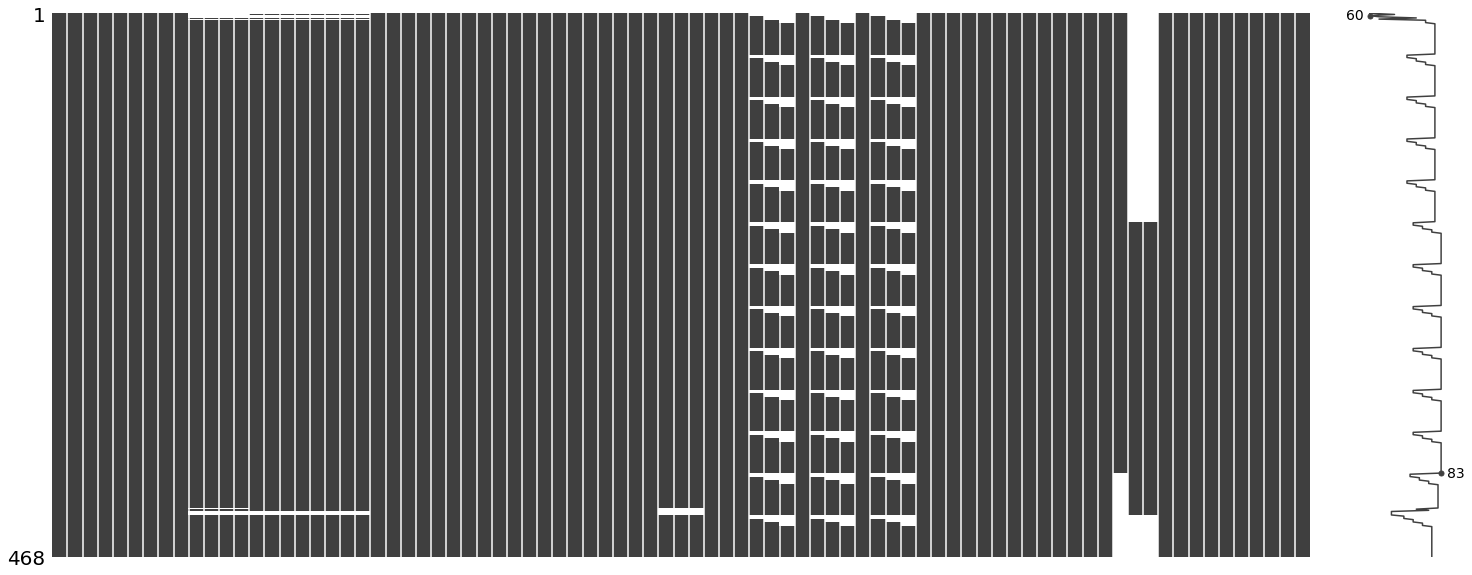

In [9]:
missingno.matrix(dataset)

In [10]:
cols = dataset.columns
cols

Index(['x', 'y', 'month', 'year', 'dt_placement', 'NUTS2_ID', 'NUTS2_NAME',
       'NUTS3_ID', 'NUTS3_NAME', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean',
       'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std',
       'ndwi_std', 'ndbi_std', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6',
       'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14',
       'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lst', 'lst_day',
       'lst_night', 'monthly_lst_min', 'monthly_lst_max', 'lst_jan_mean',
       'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'lst_jan_day_mean',
       'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean',
       'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean',
       'lst_apr_night_mean', 'rainfall', 'monthly_acc_prec',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64',
       'F_Y_GE65', 'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 

In [11]:
len(cols)

83

In [12]:
landcover = pd.read_csv(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2021_filled.csv')
landcover.columns = landcover.columns.str.lower()

In [13]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [14]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [15]:
data_years = dataset['year'].unique().tolist()

In [16]:
for year in data_years:
    frame_name = f'dataset_{year}'
    locals()[frame_name] = dataset.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [17]:
for year in data_years:
    data_name = f'dataset_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_part_{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = df_lulc.append(locals()[lc_name].iloc[[index]])

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2010
Min distance: 1.4375230102718044
Max distance: 8.554307529163877
Year: 2011
Min distance: 1.4375230102718044
Max distance: 8.554307529163877
Year: 2012
Min distance: 1.4375230102718044
Max distance: 8.554307529163877
Year: 2013
Min distance: 1.4375230102718044
Max distance: 8.554307529163877
Year: 2014
Min distance: 1.4375230102718044
Max distance: 8.554307529163877
Year: 2015
Min distance: 1.4375230102718044
Max distance: 8.554307529163877
Year: 2016
Min distance: 1.4375230102718044
Max distance: 8.554307529163877
Year: 2017
Min distance: 1.4375230102718044
Max distance: 8.554307529163877
Year: 2018
Min distance: 1.4375230102718044
Max distance: 8.554307529163877
Year: 2019
Min distance: 1.4375230102718044
Max distance: 8.554307529163877
Year: 2020
Min distance: 1.4375230102718044
Max distance: 8.554307529163877
Year: 2021
Min distance: 1.4375230102718044
Max distance: 8.554307529163877
Year: 2022
Min distance: 1.4375230102718044
Max distance: 8.554307529163877


In [18]:
dataset_final = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_part_{year}'
    dataset_final = pd.concat([dataset_final, locals()[merged_name]], ignore_index=True)

<AxesSubplot:>

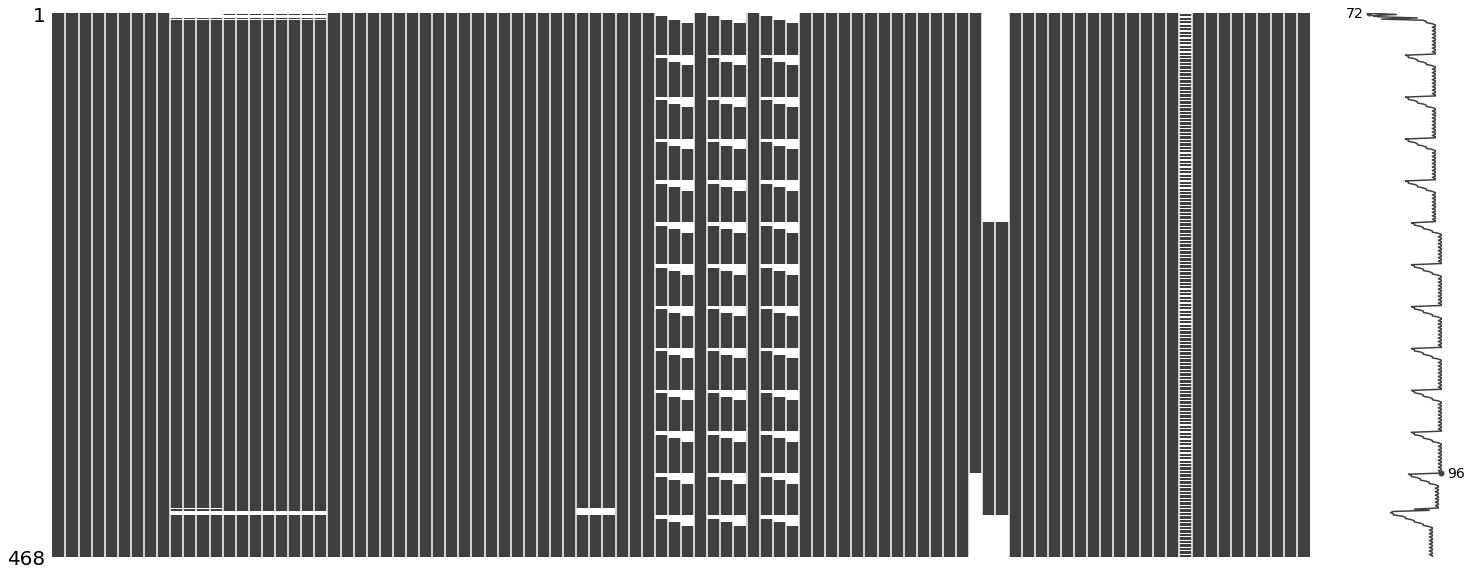

In [19]:
missingno.matrix(dataset_final)

In [20]:
cols = dataset_final.columns
cols

Index(['x', 'y', 'month', 'year', 'dt_placement', 'NUTS2_ID', 'NUTS2_NAME',
       'NUTS3_ID', 'NUTS3_NAME', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean',
       'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std',
       'ndwi_std', 'ndbi_std', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6',
       'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14',
       'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lst', 'lst_day',
       'lst_night', 'monthly_lst_min', 'monthly_lst_max', 'lst_jan_mean',
       'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'lst_jan_day_mean',
       'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean',
       'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean',
       'lst_apr_night_mean', 'rainfall', 'monthly_acc_prec',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64',
       'F_Y_GE65', 'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 

In [21]:
len(cols)

96

In [22]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv", encoding = enc, index = False)